Setup:

In [ ]:
import gc
gc.collect()

28

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

torch.cuda.empty_cache()
torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()

tokenizer = AutoTokenizer.from_pretrained('meta-llama/Meta-Llama-3-8B', use_fast=True)
model = AutoModelForCausalLM.from_pretrained('meta-llama/Meta-Llama-3-8B', dtype=torch.bfloat16, device_map="auto")
model.seqlen = model.config.max_position_embeddings

/home/mrajnoha/double-block-sparse/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 291/291 [00:11<00:00, 25.40it/s] 


In [ ]:
from llm import test_perplexity_and_response

Tests:

224
torch.Size([4096, 4096])
torch.Size([4096])
torch.Size([4096, 4096])
torch.Size([4096, 4096])


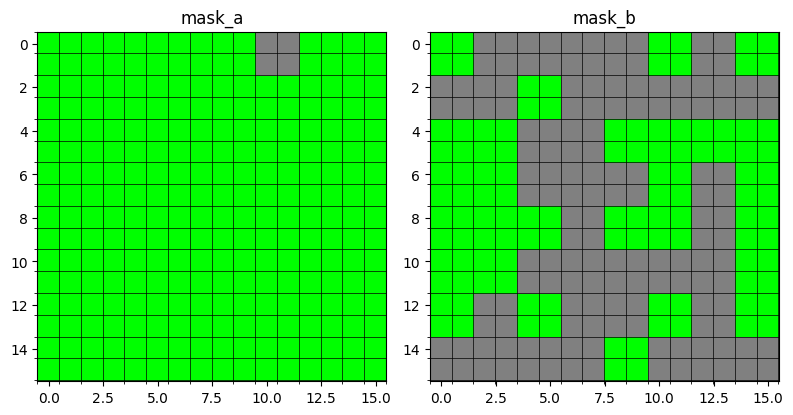

Frobenius norm: 4.28125
A.size() = torch.Size([4096, 4096])
B.size() = torch.Size([4096, 4096])
A has 4194304 non-zero entries (25.0%)
B has 4194304 non-zero entries (25.0%)
Replaced model.layers.0.self_attn.q_proj with FactorizedLinear (Bottleneck: 4096)
torch.Size([1024, 4096])
torch.Size([4096])
torch.Size([1024, 4096])
torch.Size([1024, 4096])


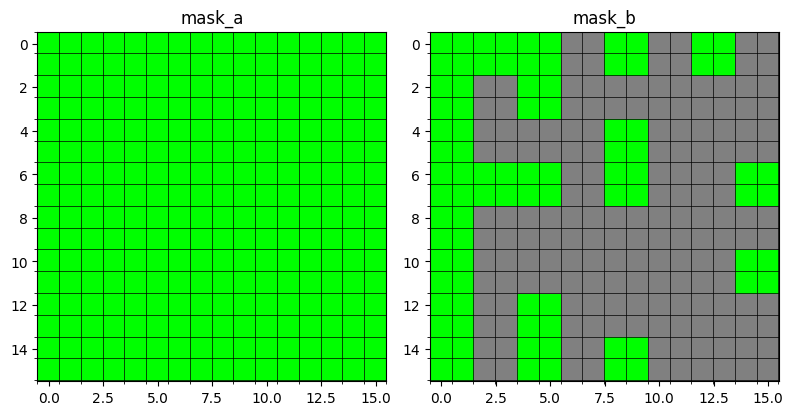

Frobenius norm: 3.53125
A.size() = torch.Size([1024, 1024])
B.size() = torch.Size([1024, 4096])
A has 1042430 non-zero entries (99.4%)
B has 1045774 non-zero entries (24.9%)
Replaced model.layers.0.self_attn.k_proj with FactorizedLinear (Bottleneck: 1024)
torch.Size([1024, 4096])
torch.Size([4096])
torch.Size([1024, 4096])
torch.Size([1024, 4096])


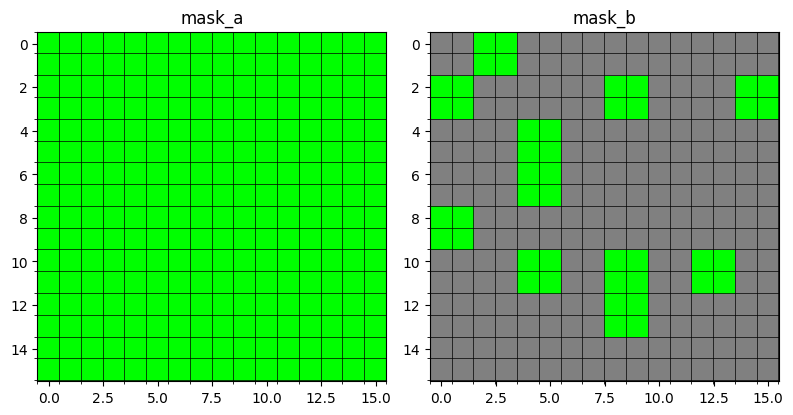

Frobenius norm: 3.765625
A.size() = torch.Size([1024, 1024])
B.size() = torch.Size([1024, 4096])
A has 1048572 non-zero entries (100.0%)
B has 1048576 non-zero entries (25.0%)
Replaced model.layers.0.self_attn.v_proj with FactorizedLinear (Bottleneck: 1024)
torch.Size([4096, 4096])
torch.Size([4096])
torch.Size([4096, 4096])
torch.Size([4096, 4096])


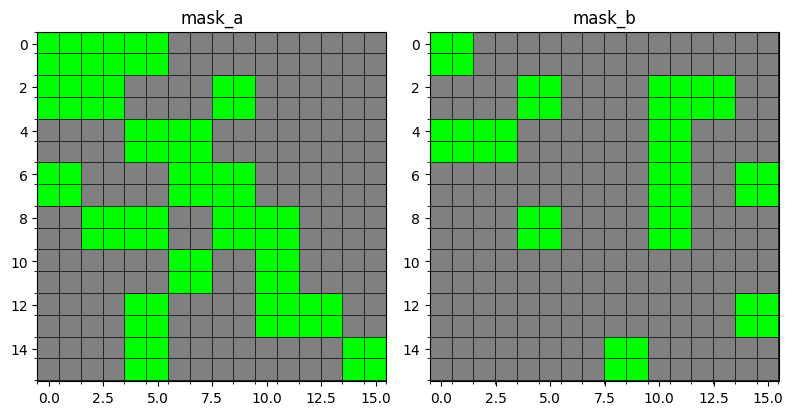

Frobenius norm: 7.78125
A.size() = torch.Size([4096, 4096])
B.size() = torch.Size([4096, 4096])
A has 4194304 non-zero entries (25.0%)
B has 4194304 non-zero entries (25.0%)
Replaced model.layers.0.self_attn.o_proj with FactorizedLinear (Bottleneck: 4096)
torch.Size([14336, 4096])
torch.Size([4096, 1])
torch.Size([4096, 14336])
torch.Size([4096, 14336])


OutOfMemoryError: CUDA out of memory. Tried to allocate 224.00 MiB. GPU 0 has a total capacity of 15.74 GiB of which 15.62 MiB is free. Including non-PyTorch memory, this process has 15.68 GiB memory in use. Of the allocated memory 15.07 GiB is allocated by PyTorch, and 447.39 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
from llm import prune_model
prune_model(model)

Cleanup:

In [ ]:
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()